<a href="https://www.kaggle.com/code/sonawanelalitsunil/crime-safety-incident-ml-12-50?scriptVersionId=253179370" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-and-safety-dataset/crime_safety_dataset.csv


## Title:
Crime & Safety Incident Dataset Analysis

## 📄 Description:
This dataset contains records of crime and public safety incidents reported across various locations and time periods. It includes key information such as:

Type of Crime (e.g., theft, assault, vandalism, burglary)

Date and Time of the incident

Location (e.g., city, neighborhood, coordinates)

Severity Level or categorization (e.g., felony, misdemeanor)

Reporting Agency or department

Status of Case (e.g., open, closed, under investigation)

This data is essential for analyzing trends in public safety, identifying high-crime areas, and assisting law enforcement agencies or policy makers in resource allocation and preventive strategies. It can also be used for creating heatmaps, predicting future crimes using machine learning, and understanding the correlation between crime and other social factors like poverty, education, or unemployment.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/crime-and-safety-dataset/crime_safety_dataset.csv")

In [3]:
df.head()

,id,date,time,crime_type,city,state,location_description,victim_age,victim_gender,victim_race
0,1,2022-09-09,18:58:57,Homicide,Philadelphia,PA,9916 Broadway,34,Male,Other
1,2,2022-07-10,12:10:59,Assault,Phoenix,AZ,6853 Oak St,13,Female,Black
2,3,2024-12-31,09:26:12,Burglary,San Antonio,TX,3760 Maple Ave,23,Male,Asian
3,4,2024-04-12,23:17:28,Vandalism,Philadelphia,PA,6781 Main St,36,Other,Asian
4,5,2023-07-19,04:49:39,Fraud,San Antonio,TX,3239 Broadway,26,Other,Other


In [4]:
df.tail()

,id,date,time,crime_type,city,state,location_description,victim_age,victim_gender,victim_race
995,996,2023-02-23,07:24:57,Assault,New York,NY,2793 Oak St,72,Female,Asian
996,997,2024-10-15,18:10:35,Drug Offense,San Jose,CA,2798 Elm St,26,Male,Other
997,998,2024-02-08,04:00:11,Assault,Houston,TX,8950 Pine St,34,Non-binary,Hispanic
998,999,2023-01-18,16:52:36,Homicide,Chicago,IL,4673 Oak St,16,Other,Hispanic
999,1000,2022-07-19,01:28:45,Homicide,Los Angeles,CA,5226 Oak St,54,Male,White


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    1000 non-null   int64 
 1   date                  1000 non-null   object
 2   time                  1000 non-null   object
 3   crime_type            1000 non-null   object
 4   city                  1000 non-null   object
 5   state                 1000 non-null   object
 6   location_description  1000 non-null   object
 7   victim_age            1000 non-null   int64 
 8   victim_gender         1000 non-null   object
 9   victim_race           1000 non-null   object
dtypes: int64(2), object(8)
memory usage: 78.3+ KB


In [6]:
df.describe()

,id,victim_age
count,1000.000000,1000.000000
mean,500.500000,52.201000
std,288.819436,22.913831
min,1.000000,12.000000
25%,250.750000,33.000000
50%,500.500000,53.000000
75%,750.250000,72.000000
max,1000.000000,90.000000


In [7]:
df.isnull().sum()

id                      0
date                    0
time                    0
crime_type              0
city                    0
state                   0
location_description    0
victim_age              0
victim_gender           0
victim_race             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

id                       int64
date                    object
time                    object
crime_type              object
city                    object
state                   object
location_description    object
victim_age               int64
victim_gender           object
victim_race             object
dtype: object

In [10]:
df.shape

(1000, 10)

In [11]:
df.columns

Index(['id', 'date', 'time', 'crime_type', 'city', 'state',
       'location_description', 'victim_age', 'victim_gender', 'victim_race'],
      dtype='object')

## Data visualizations

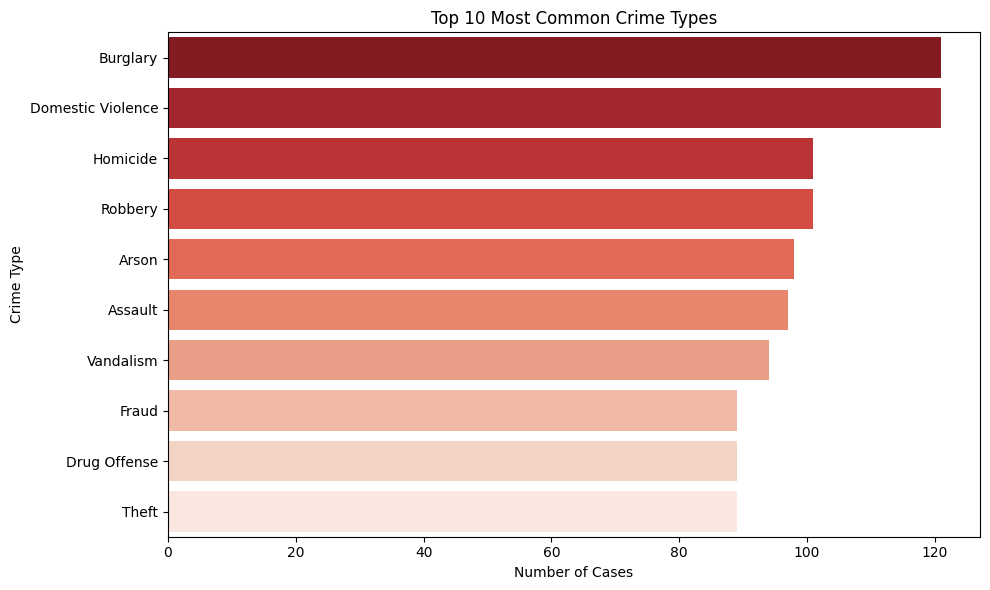

In [12]:
plt.figure(figsize=(10,6))
crime_counts = df['crime_type'].value_counts().head(10)
sns.barplot(x=crime_counts.values, y=crime_counts.index, palette='Reds_r')
plt.title('Top 10 Most Common Crime Types')
plt.xlabel('Number of Cases')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()


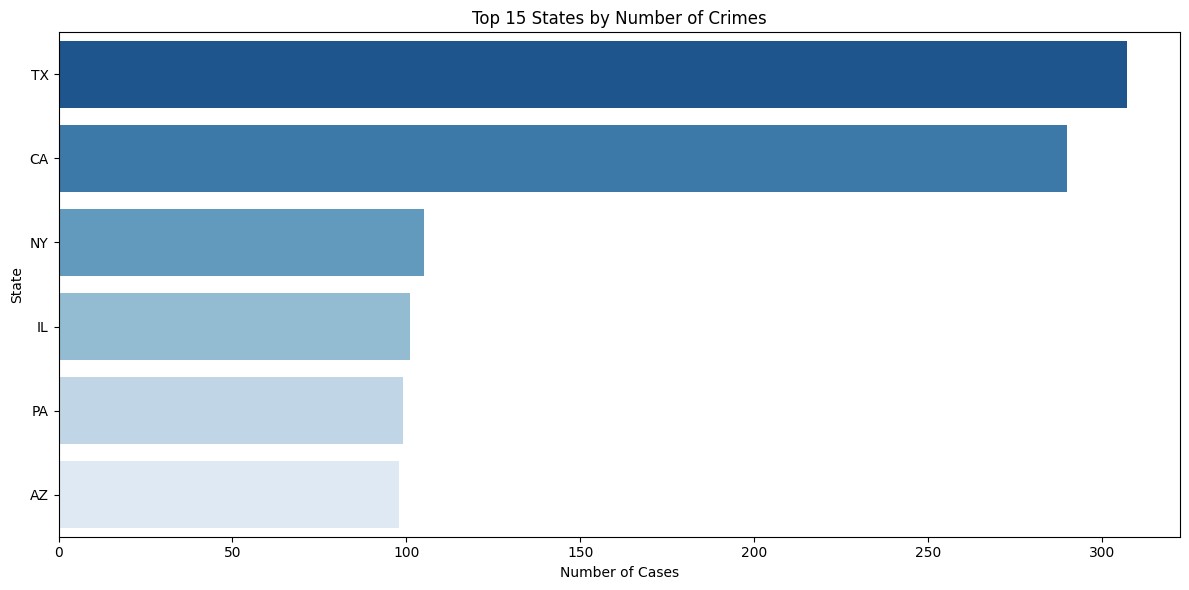

In [13]:
plt.figure(figsize=(12,6))
state_counts = df['state'].value_counts().head(15)
sns.barplot(x=state_counts.values, y=state_counts.index, palette='Blues_r')
plt.title('Top 15 States by Number of Crimes')
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()


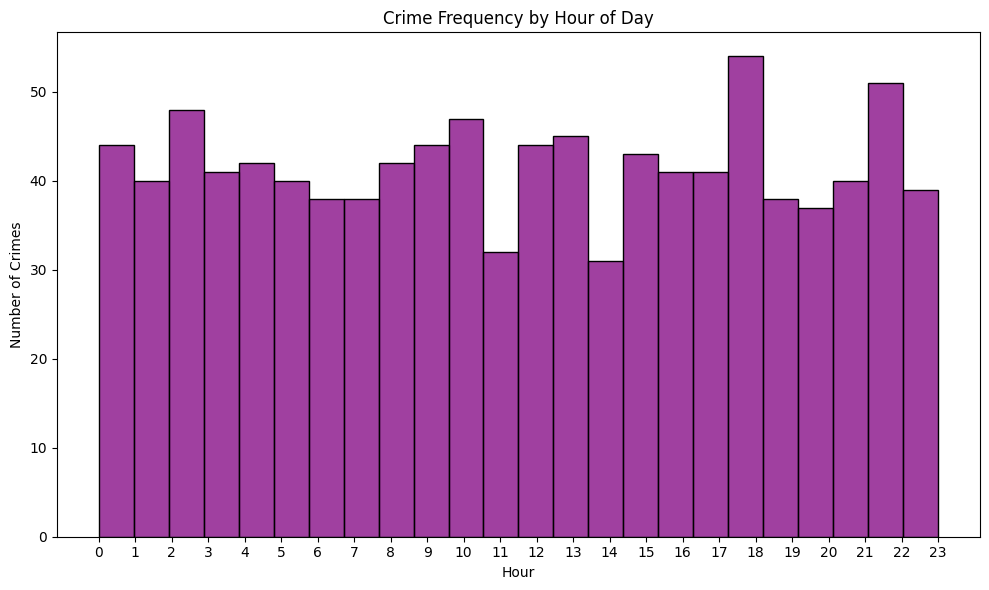

In [14]:
# Extract hour from time column
df['hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour

plt.figure(figsize=(10,6))
sns.histplot(df['hour'].dropna(), bins=24, kde=False, color='purple')
plt.title('Crime Frequency by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


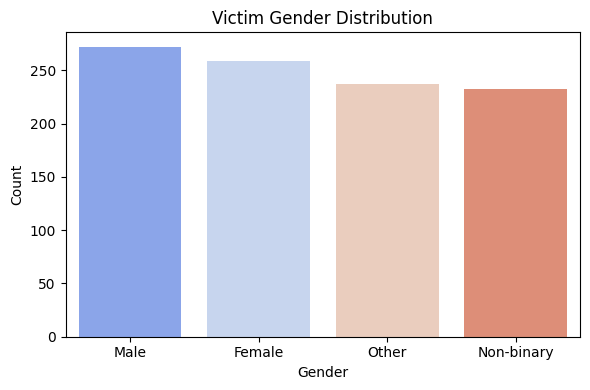

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='victim_gender', palette='coolwarm')
plt.title('Victim Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


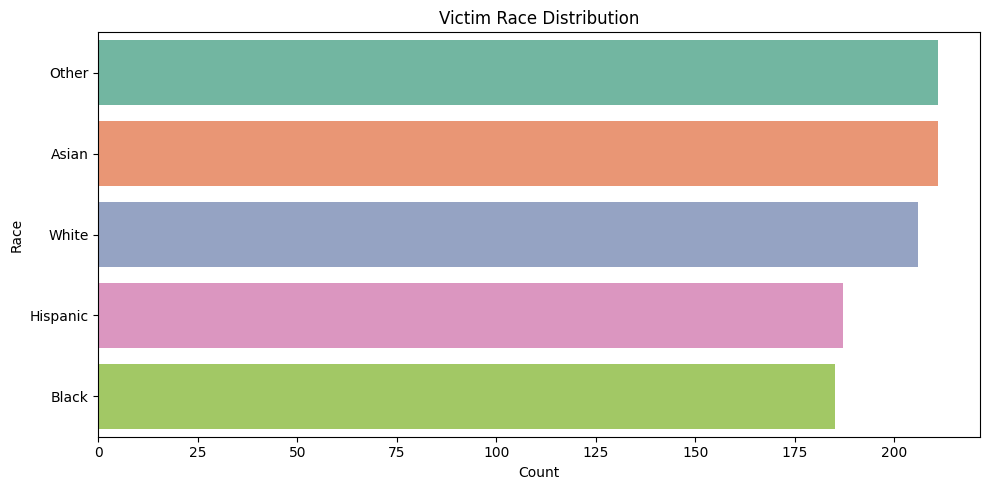

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='victim_race', order=df['victim_race'].value_counts().index, palette='Set2')
plt.title('Victim Race Distribution')
plt.xlabel('Count')
plt.ylabel('Race')
plt.tight_layout()
plt.show()


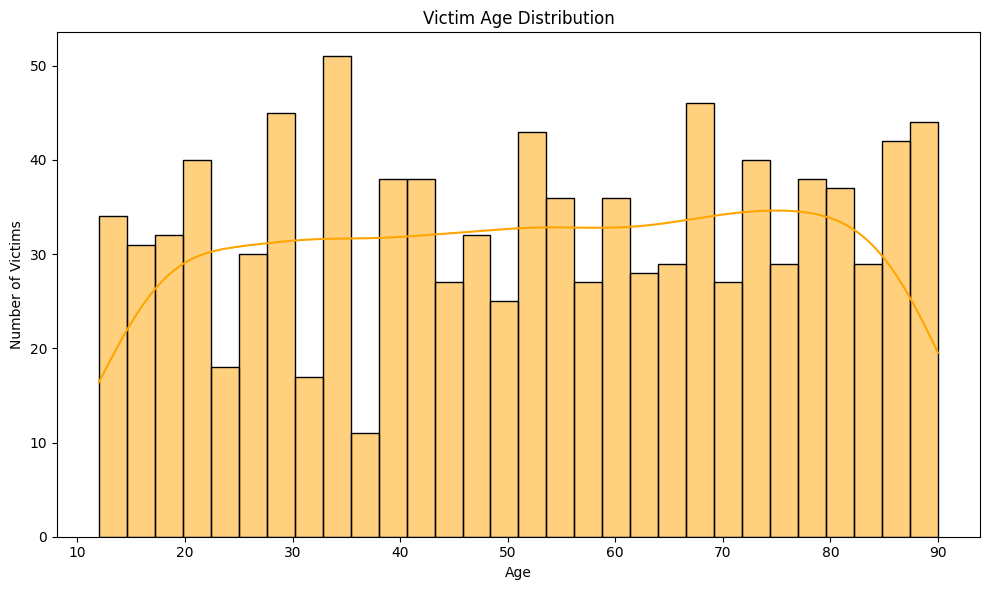

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(df['victim_age'].dropna(), bins=30, kde=True, color='orange')
plt.title('Victim Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.tight_layout()
plt.show()


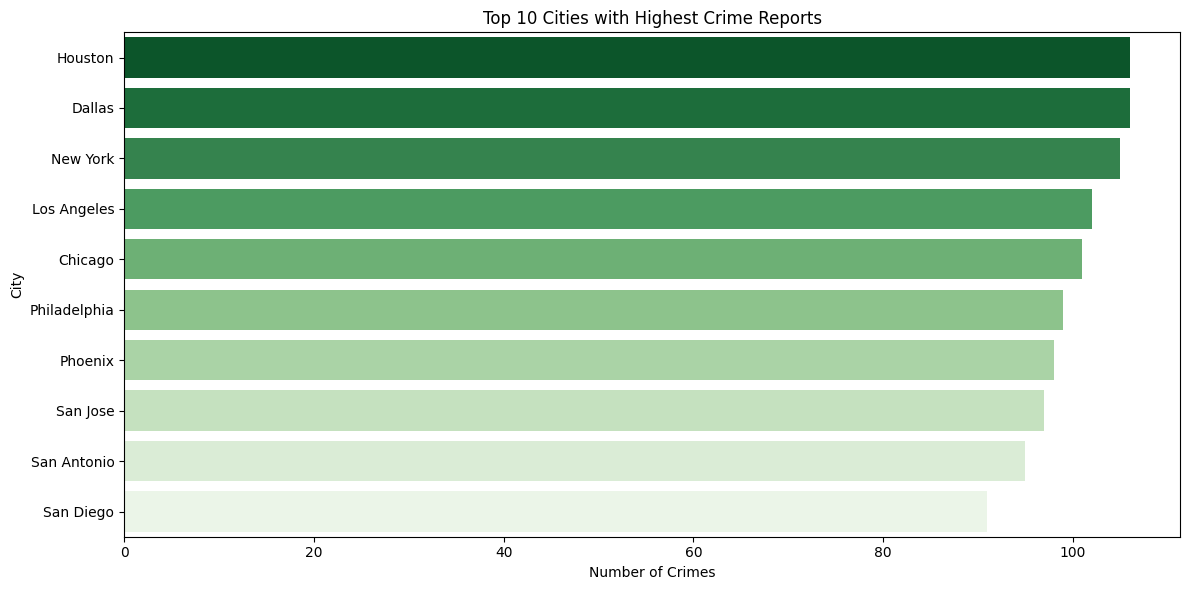

In [18]:
plt.figure(figsize=(12,6))
city_counts = df['city'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index, palette='Greens_r')
plt.title('Top 10 Cities with Highest Crime Reports')
plt.xlabel('Number of Crimes')
plt.ylabel('City')
plt.tight_layout()
plt.show()


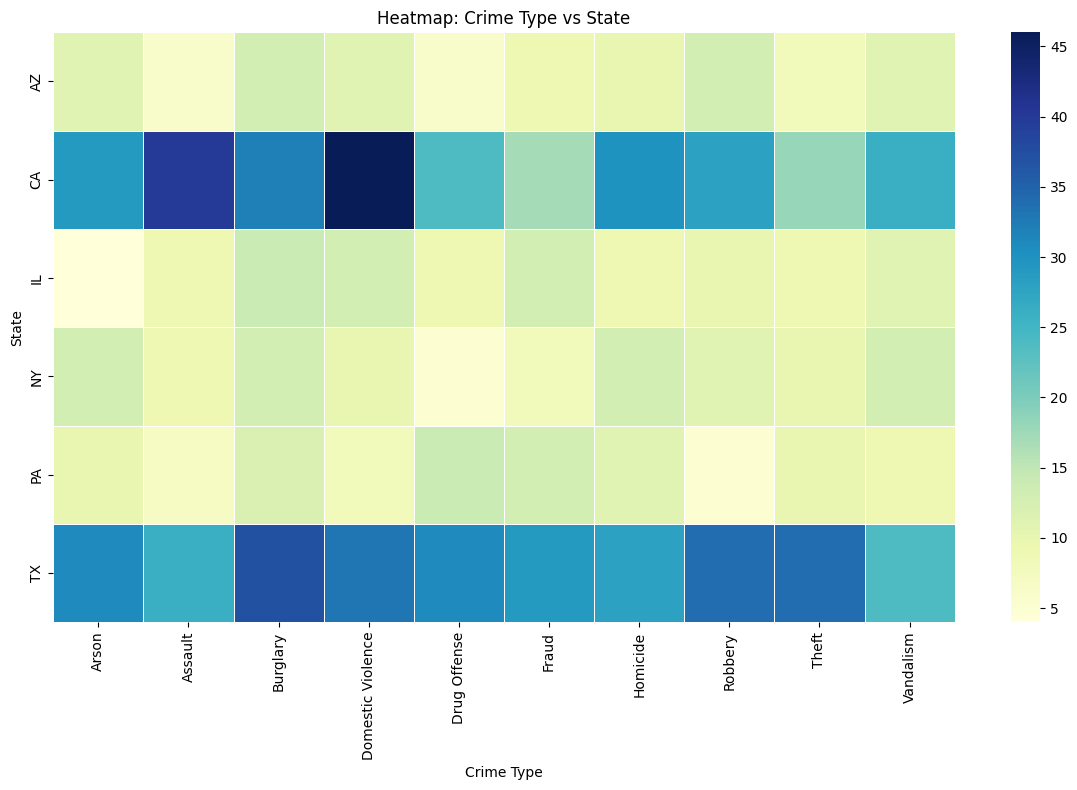

In [19]:
top_crimes = df['crime_type'].value_counts().nlargest(10).index
filtered_df = df[df['crime_type'].isin(top_crimes)]

pivot_table = pd.crosstab(filtered_df['state'], filtered_df['crime_type'])

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, cmap='YlGnBu', linewidths=0.5)
plt.title('Heatmap: Crime Type vs State')
plt.xlabel('Crime Type')
plt.ylabel('State')
plt.tight_layout()
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# Drop unnecessary columns
df = df.drop(columns=['id', 'date', 'time'])

# Drop missing values for simplicity
df.dropna(inplace=True)

# Encode all categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [22]:
# Features and target
X = df.drop('crime_type', axis=1)
y = df['crime_type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate
print("Model Accuracies (%):")
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc
    print(f"{name}: {acc:.2f}%")


Model Accuracies (%):
Logistic Regression: 12.00%
Decision Tree: 12.50%
Random Forest: 15.00%
Naive Bayes: 17.00%
Support Vector Machine: 12.50%
K-Nearest Neighbors: 14.00%


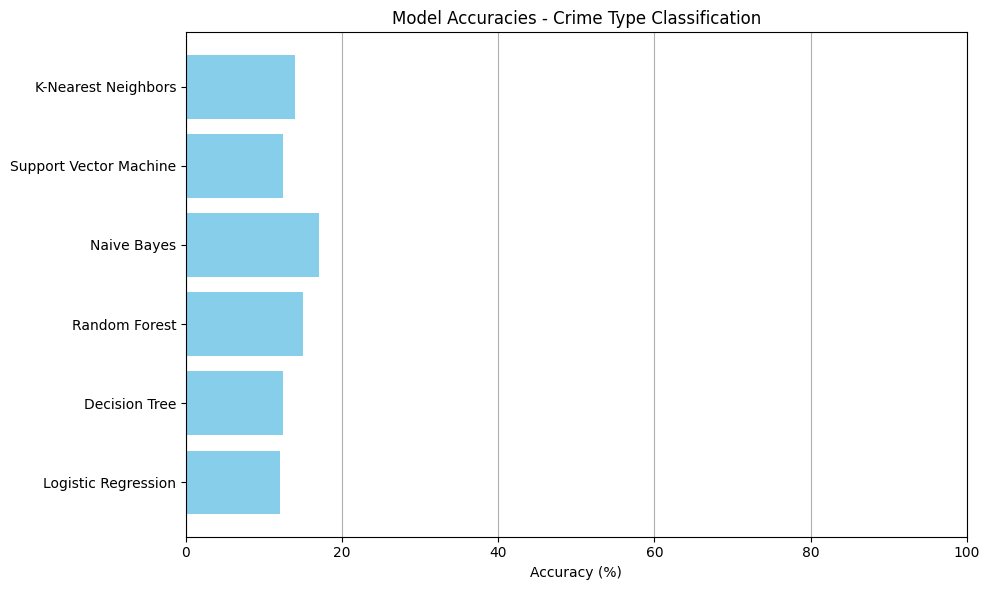

In [24]:
plt.figure(figsize=(10,6))
plt.barh(list(accuracies.keys()), list(accuracies.values()), color='skyblue')
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracies - Crime Type Classification')
plt.xlim(0, 100)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!